# Assignment 3: The "Multimodal Sentiment Engine" Challenge

**Total Marks:** 20 | **Deadline:** 7:00 PM, 22nd March, 2026 | 
**Submission:** A zip file of the folder containing this notebook, and the csv/image files you will create.


---

## Setup

Run the cell below **once** to install all required packages and download NLTK data.

In [3]:
import nltk
for pkg in ["wordnet", "averaged_perceptron_tagger_eng", "punkt_tab", "omw-1.4"]:
    nltk.download(pkg, quiet=True)
print("Setup complete!")

Setup complete!


In [7]:
import os, re, json, time, random, warnings
from collections import Counter
from itertools import combinations

from dotenv import load_dotenv
load_dotenv()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from dotenv import load_dotenv
import os

%matplotlib inline

load_dotenv()

warnings.filterwarnings("ignore")

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
LLM_MODEL = "google/gemini-2.0-flash-001"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Sentiment-bearing words to preserve during augmentation
PRESERVE_WORDS = {
    "amazing", "terrible", "awful", "excellent", "wonderful", "horrible",
    "great", "bad", "good", "worst", "best", "love", "hate", "boring",
    "fantastic", "brilliant", "pathetic", "outstanding", "dreadful",
    "superb", "mediocre",
}

print("Imports loaded. API key present:", bool(OPENROUTER_API_KEY))

Imports loaded. API key present: True


## Task 1: Data Consolidation & Classical Augmentation (5 Marks)

**Steps:**
1. Load all three CSVs and merge them
2. Train a baseline Logistic Regression on `gold_standard_100.csv` (TF-IDF features)
3. Filter `llm_labels_150.csv` -- keep only reviews where baseline confidence ≥ 0.65 AND agrees with LLM label
4. Deduplicate by review text $\rightarrow$ save `consolidated_base.csv`
5. Identify minority class, apply 2 augmentation methods (Synonym Replacement, Back Translation)
6. Quality filter augmented samples (Jaccard similarity)
7. Save `augmented_classical.csv` and `class_distribution.png`

Gold: 100, Weak: 220, LLM: 150
(29, 2)
                                              review     label
0  It has some good moments, especially the cinem...   Neutral
1  It doesn't leave a lasting impression. Neither...   Neutral
2  The story arc was frankly tedious. I tried to ...  Negative
3  While the lighting was good, the rest felt ave...   Neutral
4  This movie is a triumph in every sense. I will...  Positive


shape of the consolidated_base is: (320, 2)
Class distriubution of the new consolidated_base data:
label   
Negative    148
Neutral     112
Positive     60
Name: count, dtype: int64


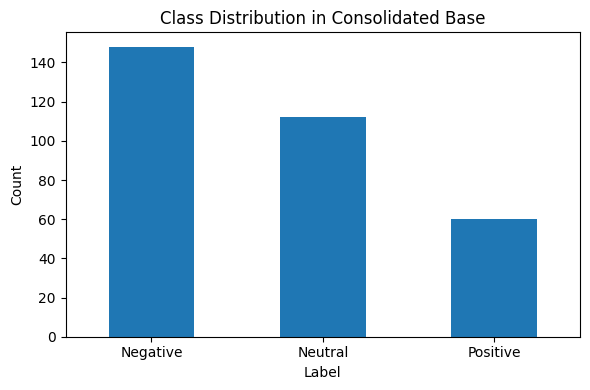

The minority class is: Positive


In [58]:
gold = pd.read_csv("gold_standard_100.csv")
weak = pd.read_csv("weak_labels_200.csv")
llm  = pd.read_csv("llm_labels_150.csv")
print(f"Gold: {len(gold)}, Weak: {len(weak)}, LLM: {len(llm)}")

def train_baseline_model(train_df, text_col="review", label_col="label"):
    """Returns (vectorizer, classifier) trained on the given dataframe."""
    vec = TfidfVectorizer(max_features=5000, stop_words="english")
    X = vec.fit_transform(train_df[text_col])
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(X, train_df[label_col])
    return vec, clf

vec, clf = train_baseline_model(gold)

#  1c. Filter LLM labels by co  nfidence 
# TODO: Predict on llm reviews, keep where confidence >= 0.65 AND prediction matches LLM label
test_X = vec.transform(llm["review"])
pred = clf.predict(test_X)
confidence = clf.predict_proba(test_X).max(axis=1)
llm_new = llm[(confidence >= 0.65) & (pred == llm["label"])]
print(llm_new.shape)
print(llm.head())
print('\n')

#  1d. Merge & deduplicate 
# TODO: Combine gold + weak + filtered_llm, drop_duplicates on "review"
# Save as consolidated_base.csv
consolidated_base = pd.concat([gold, weak, llm_new], ignore_index=True).drop_duplicates(subset=['review'])
print(f'shape of the consolidated_base is: {consolidated_base.shape}')
consolidated_base.to_csv('consolidated_base.csv', index=False)

#  1e. Class distribution analysis 
# TODO: Count per class, identify minority, plot and save class_distribution.png
print(f"Class distriubution of the new consolidated_base data:")
print(consolidated_base.value_counts(subset=['label']))
plt.figure(figsize=(6,4))
consolidated_base['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution in Consolidated Base')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'The minority class is: {consolidated_base["label"].value_counts().idxmin()}')

plt.savefig('class_distribution.png')
plt.close()

In [59]:
# 1f. Augmentation functions

def synonym_replacement(text, replace_frac=0.15):
    """Replace 15-20% of words with WordNet synonyms. Preserve sentiment-bearing words."""
    words = word_tokenize(text)
    candidate_indices = [
        i for i, word in enumerate(words)
        if word.isalpha() and word.lower() not in PRESERVE_WORDS
    ]
    
    if not candidate_indices:
        return text
    
    num_samples = max(1, int(len(candidate_indices) * replace_frac))
    sampled_indices = random.sample(candidate_indices, min(num_samples, len(candidate_indices)))
    
    def get_synonyms(word):
        synonyms = set()
        for syn in wordnet.synsets(word):
            for lemma in syn.lemmas():
                synonym = lemma.name().replace("_", " ")
                if synonym.lower() != word.lower():
                    synonyms.add(synonym)
        return list(synonyms)
    
    for i in sampled_indices:
        synonyms = get_synonyms(words[i])
        if synonyms:
            words[i] = random.choice(synonyms)
    
    return " ".join(words)


def back_translate(text, src="en", mid="hi"):
    """Translate English → Hindi → English using deep-translator."""
    
    from deep_translator import GoogleTranslator
    
    try:
        translated_mid = GoogleTranslator(source=src, target=mid).translate(text)
        time.sleep(1)
        back_translated = GoogleTranslator(source=mid, target=src).translate(translated_mid)
        
        return back_translated
    
    except Exception as e:
        print(f"[BackTranslation Error] {e}")
        return text


def quality_filter(original, augmented):
    """Return True if augmented text passes Jaccard similarity (0.30–0.95)."""
    
    def jaccard_similarity(a, b):
        set_a = set(word_tokenize(a.lower()))
        set_b = set(word_tokenize(b.lower()))
        
        if not set_a or not set_b:
            return 0
        
        intersection = len(set_a.intersection(set_b))
        union = len(set_a.union(set_b))
        return intersection / union
    
    score = jaccard_similarity(original, augmented)
    return 0.30 <= score <= 0.95


# ------------------ TEST ------------------
previous_word = "I tried to like it, I really amazing, but it failed. The pacing distracted me from everything else. It’s a hard pass from me."
new_word = synonym_replacement(previous_word)
new_word_bt = back_translate(previous_word)

print(f"Previous Word: {previous_word}")
print(f"New Word: {new_word}")
print(f"Back-translated Word: {new_word_bt}")


# 1g. Apply augmentation to minority class

minority_class = consolidated_base["label"].value_counts().idxmin()
minority_samples = consolidated_base[consolidated_base["label"] == minority_class]

augmented_samples = []

for _, row in minority_samples.iterrows():
    original_text = row["review"]
    
    # Synonym replacement
    aug_syn = synonym_replacement(original_text)
    if quality_filter(original_text, aug_syn):
        augmented_samples.append({
            "review": aug_syn,
            "label": row["label"]
        })
    
    # Back translation
    aug_bt = back_translate(original_text)
    if quality_filter(original_text, aug_bt):
        augmented_samples.append({
            "review": aug_bt,
            "label": row["label"]
        })

# Save to CSV
augmented_samples_df = pd.DataFrame(augmented_samples)
print(augmented_samples_df.value_counts(subset=['label']))
augmented_samples_df.to_csv("augmented_classical.csv", index=False)

Previous Word: I tried to like it, I really amazing, but it failed. The pacing distracted me from everything else. It’s a hard pass from me.
New Word: 1 tried to alike it , I really amazing , but it failed . The pacing distracted me from everything else . It ’ s a unvoiced pass from me .
Back-translated Word: I tried to like it, I'm really amazing, but it failed. The motion distracted me from everything else. This is a difficult path for me.
label   
Positive    117
Name: count, dtype: int64


## Task 2: LLM-Based Synthetic Review Generation (5 Marks)

**Steps:**
1. Design a few-shot prompt with 3-4 gold-standard examples
2. Use OpenRouter API (via `openai` package) to generate 300 synthetic reviews in batches of 20
3. Calculate diversity metrics: Self-BLEU per class
4. Run sentiment consistency check with baseline model $\rightarrow$ flag mismatches
5. Save `llm_generated_300.csv`, `llm_generated_flagged.csv`, `prompt_template.txt`, `diversity_report.txt`

In [57]:
from openai import OpenAI

client = OpenAI(base_url=OPENROUTER_BASE_URL, api_key=OPENROUTER_API_KEY)

#  2a. Design your few-shot prompt 
# TODO: Build a prompt string with 3-4 example reviews from gold standard
# Instruct the LLM to output JSON: [{"review": "...", "sentiment": "Positive", "movie": "..."}]
PROMPT_TEMPLATE = """You are a movie review generator.
Generate EXACTLY 20 movie reviews.

Distribution:
- 10 Positive
- 7 Negative
- 3 Neutral

Each review must include:
- review (text)
- sentiment (Positive/Negative/Neutral)
- movie (title)

Example reviews:
1. "This movie is a triumph in every sense. Highly recommended for everyone.", sentiment: "Positive", movie: "Inception"
2. "I have never been so bored in my life. The score was frankly cringe-worthy. Avoid this at all costs.", sentiment: "Negative", movie: "The Room"
3. "The movie was okay, nothing special but not bad either.", sentiment: "Neutral", movie: "The Matrix"
4. "I was completely blown away by this film. The lead actor delivered a refreshing performance. I will be thinking about this for days.", sentiment: "Positive", movie: "Parasite"

Return ONLY valid JSON in this format:
[
  {"review": "...", "sentiment": "Positive", "movie": "..."},
  ...
]
"""


# Save prompt to file
with open("prompt_template.txt", "w", encoding="utf-8") as f:
    f.write(PROMPT_TEMPLATE)

#  2b. Generate reviews in batches 
# TODO: Loop to generate ~300 reviews in batches of 20
# Target distribution: ~150 Positive, ~100 Negative, ~50 Neutral

all_reviews = []

def extract_json(text):
    cleaned = re.sub(r"```json\s*|\s*```", "", text.strip())
    return json.loads(cleaned)

for i in range(15):
    response = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{"role": "system", "content": PROMPT_TEMPLATE}],
        max_tokens=4000,
        temperature=1.0,
        n=20,
        top_p=1.0,
        presence_penalty=0.5,   # encourages new concepts
        frequency_penalty=0.5   # discourages repeated words
    )

    # Parse JSON response, handle errors
    try:
        generated_reviews = response.choices[0].message.content
        data = extract_json(generated_reviews)
        all_reviews.extend(data)
    except json.JSONDecodeError:
        print(f"JSON parsing error for batch {i}. Response: {generated_reviews}")
    except Exception as e:
        print(f"Error processing batch {i}: {e}")

all_reviews_df = pd.DataFrame(all_reviews)
all_reviews_df.to_csv("llm_generated_300.csv", index=False)


#  2c. Diversity metrics 
# TODO: Calculate Self-BLEU per sentiment class using nltk.translate.bleu_score
def compute_self_bleu(texts):
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    
    smoothie = SmoothingFunction().method4
    scores = []
    
    for i in range(len(texts)):
        reference = [word_tokenize(texts[j]) for j in range(len(texts)) if j != i]
        candidate = word_tokenize(texts[i])
        score = sentence_bleu(reference, candidate, smoothing_function=smoothie)
        scores.append(score)
    
    return np.mean(scores)

self_bleu_scores = {}
for sentiment, group in all_reviews_df.groupby('sentiment'):
    texts = group['review'].tolist()
    
    score = compute_self_bleu(texts)
    self_bleu_scores[sentiment] = score

with open("diversity_report.txt", "w", encoding="utf-8") as f:
    for sentiment, score in self_bleu_scores.items():
        f.write(f"{sentiment}: {score}\n")


#  2d. Sentiment consistency check 
# TODO: Use baseline model (vec, clf) to predict sentiment of each generated review
# TODO: Flag mismatches, save llm_generated_flagged.csv
SENTIMENT_PROMPT = """
Classify the sentiment of the following movie review.

Return ONLY one word:
Positive / Negative / Neutral

Review:
"{review}"
"""
def predict_sentiment(review):
    response = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{"role": "system", "content": SENTIMENT_PROMPT.format(review=review)}],
        max_tokens=10,
        temperature=0.0,    # For consistency, we want deterministic output
        n=1,
    )
    return response.choices[0].message.content.strip()
all_reviews_df['predicted_sentiment'] = all_reviews_df['review'].apply(predict_sentiment)
all_reviews_df['sentiment_match'] = all_reviews_df.apply(lambda row: row['sentiment'] == row['predicted_sentiment'], axis=1)
flagged_reviews_df = all_reviews_df[~all_reviews_df['sentiment_match']]
flagged_reviews_df.to_csv("llm_generated_flagged.csv", index=False)


#  2e. Save outputs 
# TODO: Save llm_generated_300.csv and diversity_report.txt

temp = 0.7 
{'Negative': np.float64(0.6562285974670435), 'Neutral': np.float64(0.5517690221386383), 'Positive': np.float64(0.6788646730427537)}

temp = 1.0
{'Negative': np.float64(0.5037042988661624), 'Neutral': np.float64(0.3439312285632707), 'Positive': np.float64(0.49943155783448123)}

temp = 1.0, top_p = 1.0
{'Negative': np.float64(0.4662456506596136), 'Neutral': np.float64(0.3598400464052391), 'Positive': np.float64(0.501312994142405)}

temp = 1.0, top_p = 1.0, presence_penalty=0.5, frequency_penalty=0.5


## Task 3: Multilingual Sentiment Translation (4 Marks)

**Steps:**
1. Sample 100 reviews (40 Pos, 40 Neg, 20 Neu), prioritize shorter reviews
2. Translate English $\rightarrow$ Hindi using `deep-translator` (`GoogleTranslator`)
3. Back-translate Hindi $\rightarrow$ English, compute BLEU score (threshold ≥ 0.3)
4. Check sentiment preservation on back-translated text
5. Manually verify 5 random samples
6. Save `bilingual_reviews.csv` with `bleu_score` and `quality_flag` columns

In [70]:
from deep_translator import GoogleTranslator
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

#  3a. Strategic sampling 
# TODO: From consolidated_base, sample 100 reviews (40 Pos, 40 Neg, 20 Neu)
# Prioritize shorter reviews (sort by length, take shortest)
sampled_reviews = []
consolidated_base_sorted = consolidated_base.copy()
consolidated_base_sorted = consolidated_base_sorted.sort_values(by='review', key=lambda x: x.str.len())
for label in ['Positive', 'Negative', 'Neutral']:
    sample = consolidated_base_sorted[consolidated_base_sorted["label"]==label]
    if(label=="Positive"):
        sampled_reviews.extend([sample['review'].head(40).tolist(), sample['label'].head(40).tolist()])
    elif(label=="Negative"):
        sampled_reviews.extend([sample['review'].head(40).tolist(), sample['label'].head(40).tolist()])
    elif(label=="Neutral"):
        sampled_reviews.extend([sample['review'].head(20).tolist(), sample['label'].head(20).tolist()])

strategic_sampling_df = pd.DataFrame({
    'review': [item for sublist in sampled_reviews[::2] for item in sublist],
    'label': [item for sublist in sampled_reviews[1::2] for item in sublist]
})
#  3b. Translation pipeline 
# TODO: Translate each review English $\rightarrow$ Hindi using GoogleTranslator(source='en', target='hi')
# Add time.sleep(0.5) between calls to avoid rate limits
def translation(text):
    try:
        translated_mid = GoogleTranslator(source='en', target='hi').translate(text)
        time.sleep(0.5)
        return translated_mid

    except Exception as e:
        print(f"[Translation Error] {e}")
        return text

strategic_sampling_df['hindi'] = strategic_sampling_df['review'].apply(translation)

#  3c. Back-translation & BLEU 
# TODO: Translate Hindi $\rightarrow$ English
# Compute sentence BLEU between original and back-translated
# quality_flag = "PASS" if BLEU >= 0.3, else "FAIL"
def back_translation(text):
    try:
        translated_mid = GoogleTranslator(source='hi', target='en').translate(text)
        time.sleep(0.5)
        return translated_mid

    except Exception as e:
        print(f"[Translation Error] {e}")
        return text
    
strategic_sampling_df['back_translated'] = strategic_sampling_df['hindi'].apply(back_translation)
def bleu_score(original, back_translated):
    smoothie = SmoothingFunction().method4
    reference = [word_tokenize(original)]
    candidate = word_tokenize(back_translated)
    return sentence_bleu(reference, candidate, smoothing_function=smoothie)
strategic_sampling_df['bleu_score'] = strategic_sampling_df.apply(lambda row: bleu_score(row['review'], row['back_translated']), axis=1)
strategic_sampling_df['quality_flag'] = strategic_sampling_df['bleu_score'].apply(lambda x: "PASS" if x >= 0.3 else "FAIL")

#  3d. Sentiment preservation check 
# TODO: Predict sentiment on back-translated text, compare with original label
strategic_sampling_df['predicted_sentiment'] = strategic_sampling_df['back_translated'].apply(predict_sentiment)
strategic_sampling_df['sentiment_match'] = strategic_sampling_df.apply(lambda row: row['predicted_sentiment'] == row['label'], axis=1)

#  3e. Manual verification 
# TODO: Print 5 random samples for inspection
print(strategic_sampling_df.sample(5))

#  3f. Save 
# TODO: Save bilingual_reviews.csv with columns:
# review, label, hindi, back_translated, bleu_score, quality_flag
strategic_sampling_df.to_csv("bilingual_reviews.csv", index=False)

                                               review     label  \
83  It doesn't leave a lasting impression. It was....   Neutral   
53  I want my two hours back. Zero stars if I coul...  Negative   
70  A refreshing take on a tired genre. I can't wa...  Negative   
45  I want my two hours back. It’s a hard pass fro...  Negative   
44  A frustrating experience. Avoid this at all co...  Negative   

                                                hindi  \
83    यह कोई स्थायी प्रभाव नहीं छोड़ता. यह... ठीक था.   
53  मुझे अपने दो घंटे वापस चाहिए। यदि मैं इसे दे स...   
70  एक थकी हुई शैली पर एक ताज़ा प्रस्तुति। मैं इसे...   
45  मुझे अपने दो घंटे वापस चाहिए। यह मेरे लिए एक क...   
44          एक निराशाजनक अनुभव. इससे हर कीमत पर बचें.   

                                      back_translated  bleu_score  \
83  It does not leave any lasting effect. It was.....    0.254509   
53  I want my two hours back. Zero stars if I coul...    1.000000   
70  A refreshing take on a tired genre. I can't

## Task 4: Multimodal Audio Generation (4 Marks)

**Steps:**
1. Select 30 reviews (10 per class) of varying lengths
2. Use `gTTS` to generate audio (`tld="com"`), convert mp3$\rightarrow$wav via `librosa`+`soundfile`
3. Extract audio features with `librosa`: duration, spectral centroid, zero crossing rate, MFCCs
4. Use `openai-whisper` (tiny model) to transcribe audio back to text, compute WER
5. Save `audio_samples/` folder, `audio_features.csv`, `audio_validation.csv`

In [ ]:
from gtts import gTTS
import librosa, soundfile as sf

#  4a. Select 30 reviews (10 per class) 
# TODO: Sample from consolidated_base, mix short and long reviews
audio_samples_df = consolidated_base.groupby('label').apply(lambda x: x.sample(10, random_state=RANDOM_SEED)).reset_index(drop=True)


#  4b. TTS generation 
# TODO: For each review, generate audio with gTTS (tld="com")
# Save as mp3, then load with librosa and re-save as .wav via soundfile
os.makedirs("audio_samples", exist_ok=True)
def toaudio(text):
    tts = gTTS(text, tld="com", lang="en")
    path = os.path.join("audio_samples", re.sub(r'\W+', '_', text[:30]) + ".mp3")
    tts.save(path)
    y, sr = librosa.load(path, sr=16000)
    sf.write("audio_samples/" + re.sub(r'\W+', '_', text[:30]) + ".wav", y, sr)

audio_samples_df['review'].apply(toaudio)


#  4c. Audio feature extraction 
# TODO: For each wav, extract with librosa:
#   - duration (librosa.get_duration)
#   - spectral centroid (librosa.feature.spectral_centroid)
#   - zero crossing rate (librosa.feature.zero_crossing_rate)
#   - MFCCs (librosa.feature.mfcc, n_mfcc=13, take mean)
# Save audio_features.csv
def extract_audio(text):
    path = os.path.join("audio_samples", re.sub(r'\W+', '_', text[:30]) + ".wav")
    y, sr = librosa.load(path, sr=16000)

    duration = librosa.get_duration(y=y, sr=sr)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    zero_crossing_rate = librosa.feature.zero_crossing_rate(y=y)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13))

    return pd.Series({
        'duration': duration,
        'spectral_centroid': spectral_centroid.mean(),
        'zero_crossing_rate': zero_crossing_rate.mean(),
        'mfcc': mfcc
    })
audio_samples_list = []
for review in audio_samples_df['review']:
    audio_samples_list.append(extract_audio(review))
audio_features_df = pd.DataFrame(audio_samples_list)
audio_features_df.to_csv("audio_features.csv", index=False)


#  4d. Whisper round-trip validation 
# TODO: Transcribe each wav with Whisper
# Compute WER (word-level Levenshtein distance / reference word count)
# Flag samples with WER > 0.25
# Save audio_validation.csv
import whisper

_whisper_model = whisper.load_model("tiny")

def transcribe(text):
    path = os.path.join("audio_samples", re.sub(r'\W+', '_', text[:30]) + ".wav")
    result = _whisper_model.transcribe(path)
    return result["text"]
audio_validation_df = audio_samples_df.copy()
audio_samples_df["transcribed_text"] = audio_samples_df['review'].apply(transcribe)

from jiwer import wer
def wer_score(original_text, transcribed_text):
    score = wer(original_text, transcribed_text)
    return score
audio_samples_df['wer_score'] = audio_samples_df.apply(lambda row: wer_score(row['review'], row['transcribed_text']), axis=1)
audio_samples_df['flag'] = audio_samples_df['wer_score'].apply(lambda x: "FAIL" if x > 0.25 else "PASS")
audio_samples_df.to_csv('audio_validation.csv', index=False)

## Task 5: Final Dataset Assembly & Model Evaluation (2 Marks)

**Steps:**
1. Merge all datasets: `consolidated_base.csv` + `augmented_classical.csv` + `llm_generated_300.csv` (excluding flagged) + English text from `bilingual_reviews.csv`
2. Deduplicate $\rightarrow$ save `final_augmented_dataset.csv`
3. Use `BlackBoxEvaluator` from `evaluator.py` to compare baseline vs augmented accuracy

In [87]:
from evaluator import BlackBoxEvaluator

#  5a. Assemble final dataset 
# TODO: Load consolidated_base, augmented_classical, llm_generated_300, bilingual_reviews
# Exclude flagged LLM reviews
# Merge all, deduplicate on "review" column
# Save final_augmented_dataset.csv
consolidated_base = pd.read_csv("consolidated_base.csv")
augmented_classical = pd.read_csv("augmented_classical.csv")
llm_generated = pd.read_csv("llm_generated_300.csv")
bilingual_reviews = pd.read_csv("bilingual_reviews.csv")
final_augmented = pd.concat([consolidated_base, augmented_classical, llm_generated, bilingual_reviews], ignore_index=True).drop_duplicates(subset=['review'])
final_augmented.to_csv("final_augmented_dataset.csv", index=False)

#  5b. Black-Box Evaluation 
evaluator = BlackBoxEvaluator()
test_df = pd.read_csv("gold_standard_100.csv")

# Baseline evaluation (small dataset only)
# TODO: baseline_acc = evaluator.run_evaluation(consolidated_base, test_df)
baseline_acc = evaluator.run_evaluation(consolidated_base, test_df)

# Augmented evaluation (full dataset)
# TODO: augmented_acc = evaluator.run_evaluation(final_augmented, test_df)
augmented_acc = evaluator.run_evaluation(final_augmented, test_df)

# Print comparison
print(f"Baseline accuracy:  {baseline_acc:.2%}")
print(f"Augmented accuracy: {augmented_acc:.2%}")
print(f"Improvement:        {augmented_acc - baseline_acc:+.2%}")

Initializing Black-Box Embedder...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Embedder loaded successfully.

--- Evaluating: Model ---
Training on 220 samples (excluded 100 test overlaps)...
Accuracy: 75.00%
Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.84      0.65        25
     Neutral       0.86      0.66      0.75        47
    Positive       0.96      0.82      0.88        28

    accuracy                           0.75       100
   macro avg       0.78      0.77      0.76       100
weighted avg       0.80      0.75      0.76       100

----------------------------------------

--- Evaluating: Model ---
Training on 637 samples (excluded 100 test overlaps)...
Accuracy: 73.00%
Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.80      0.65        25
     Neutral       0.89      0.70      0.79        47
    Positive       0.91      0.71      0.80        28
         nan       0.00      0.00      0.00         0

    accuracy                  